In [2]:
import pandas as pd

# Laad de originele datasets
monthly_df = pd.read_csv("data.csv")
global_df = pd.read_csv("global-data-on-sustainable-energy (1).csv")


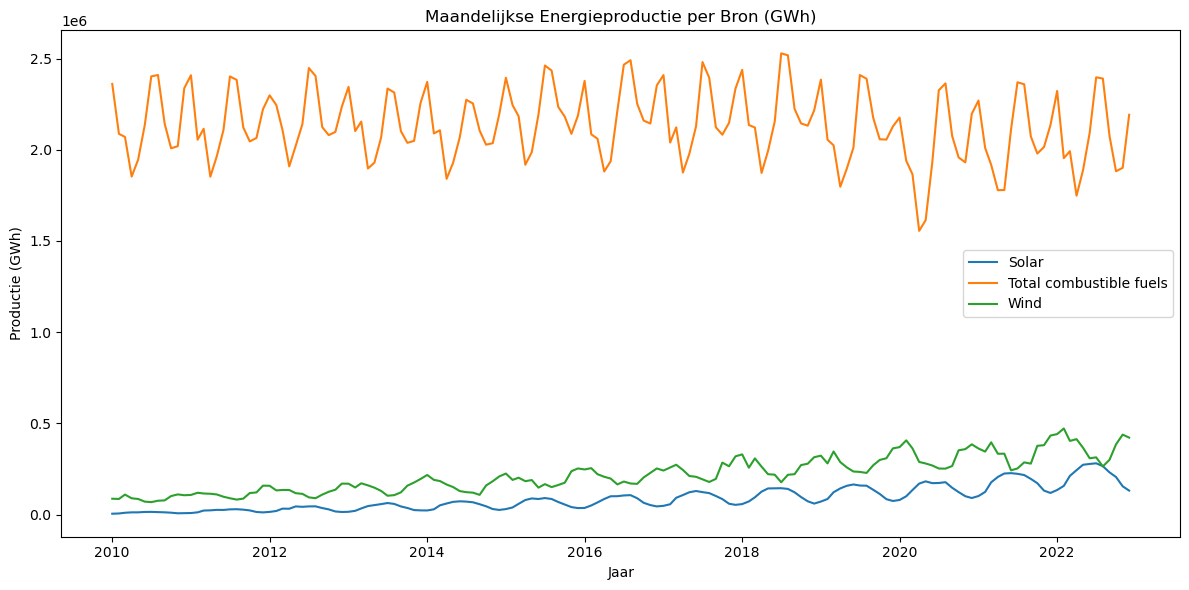

In [3]:
import matplotlib.pyplot as plt

main_sources = ['Solar', 'Wind', 'Total combustible fuels']
df = monthly_df[monthly_df['PRODUCT'].isin(main_sources)].copy()
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str))
pivot = df.pivot_table(index='DATE', columns='PRODUCT', values='VALUE', aggfunc='sum').dropna()

plt.figure(figsize=(12, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)
plt.title("Maandelijkse Energieproductie per Bron (GWh)")
plt.xlabel("Jaar")
plt.ylabel("Productie (GWh)")
plt.legend()
plt.tight_layout()
plt.show()


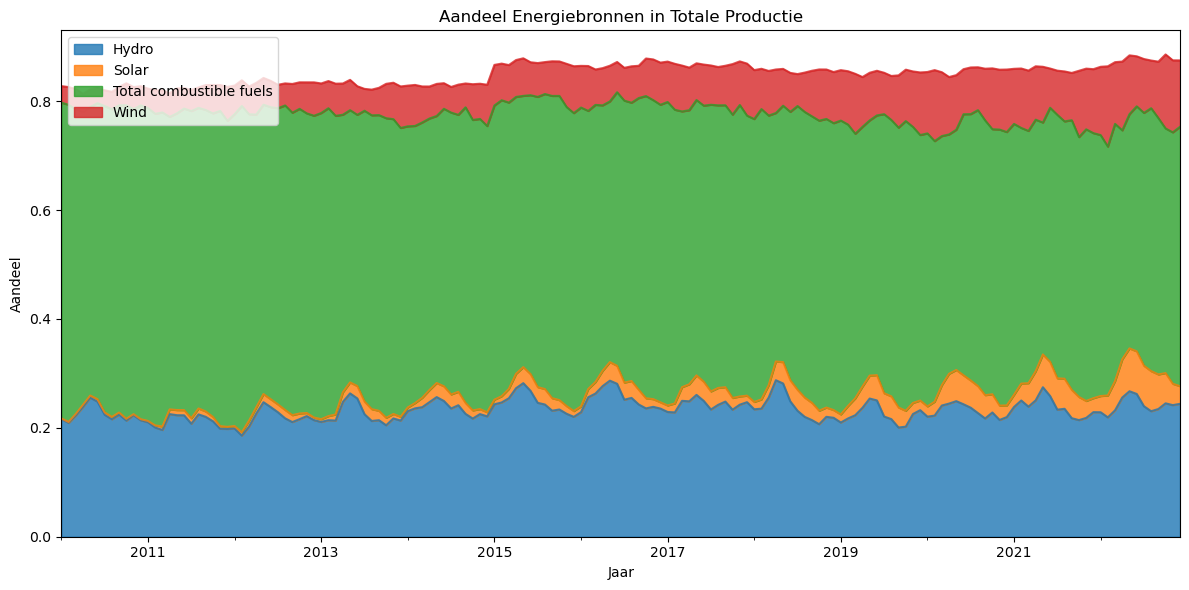

In [4]:
stack_sources = ['Solar', 'Wind', 'Hydro', 'Total combustible fuels']
df = monthly_df[monthly_df['PRODUCT'].isin(stack_sources)].copy()
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str))
pivot_share = df.pivot_table(index='DATE', columns='PRODUCT', values='share', aggfunc='mean').fillna(0)

pivot_share.plot.area(figsize=(12, 6), alpha=0.8)
plt.title("Aandeel Energiebronnen in Totale Productie")
plt.xlabel("Jaar")
plt.ylabel("Aandeel")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import plotly.express as px

# Kolomnaam instellen
col = 'Renewable energy share in the total final energy consumption (%)'

# Filter op rijen met geldige waarden
filtered = global_df[['Entity', 'Year', col]].dropna()

# Kies per land het laatste jaar met data
latest = filtered.loc[filtered.groupby('Entity')['Year'].idxmax()].copy()
latest.rename(columns={col: 'Renewable Share (%)'}, inplace=True)

# Plot met Plotly
fig = px.choropleth(
    latest,
    locations="Entity",
    locationmode="country names",
    color="Renewable Share (%)",
    color_continuous_scale="YlGn",
    title="Laatste Beschikbare Renewable Energy Share per Land",
    hover_name="Entity",
    hover_data={"Year": True}
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type="natural earth"
    ),
    coloraxis_colorbar=dict(
        title="% Renewable",
        ticks="outside"
    )
)

fig.show()




In [18]:
df = global_df[global_df['Year'] == 2019].copy()
df = df[[
    'Entity', 'gdp_per_capita',
    'Renewable energy share in the total final energy consumption (%)',
    'Access to electricity (% of population)',
    'Access to clean fuels for cooking'
]].dropna()

fig = px.scatter(df,
    x="gdp_per_capita",
    y="Renewable energy share in the total final energy consumption (%)",
    size="Access to electricity (% of population)",
    color="Access to clean fuels for cooking",
    hover_name="Entity",
    size_max=50,
    title="GDP vs. Renewable Share (2020)",
    labels={"gdp_per_capita": "GDP per capita", 
            "Renewable energy share in the total final energy consumption (%)": "Renewable Share (%)"}
)
fig.show()


c:\Users\jorda\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight

C:\Users\jorda\AppData\Local\Temp\ipykernel_54832\2971341400.py:20: UserWarning:

The figure layout has changed to tight



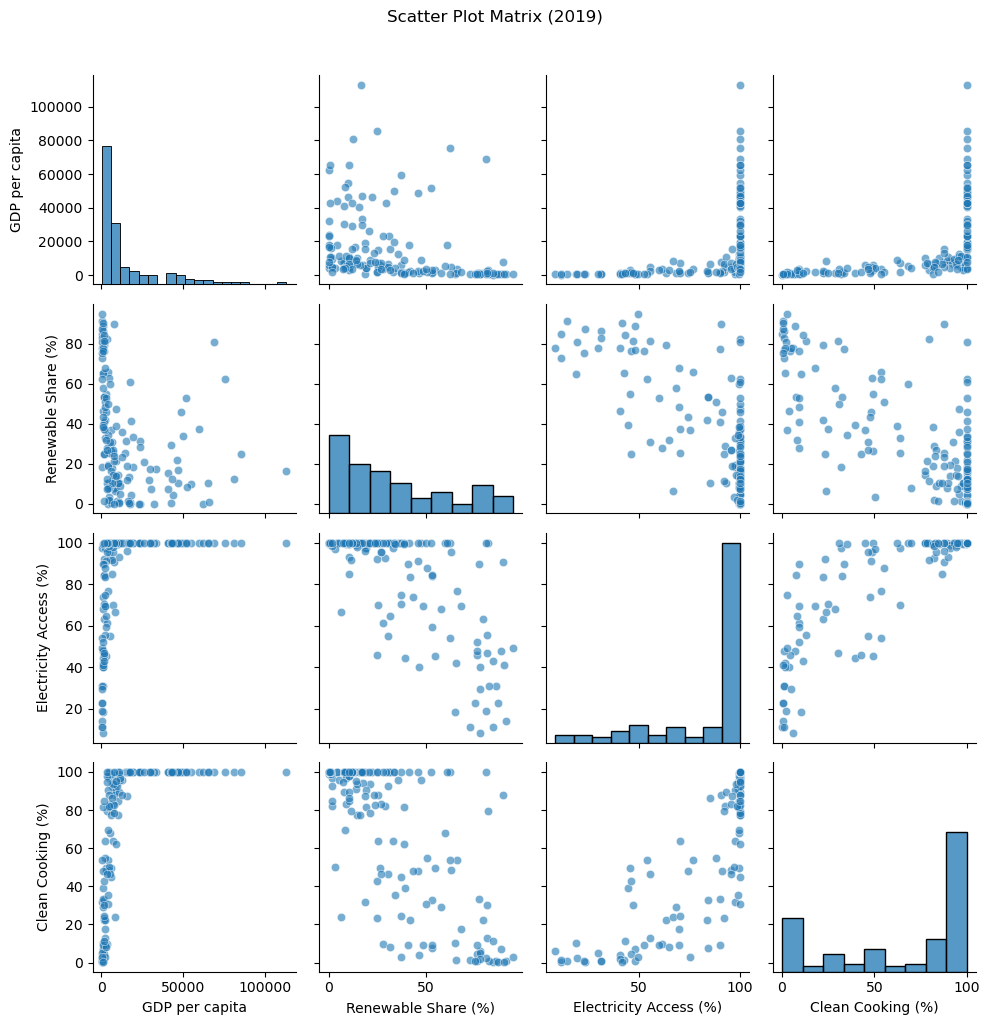

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Kies een recent jaar met voldoende data
year = 2019
cols = [
    'gdp_per_capita',
    'Renewable energy share in the total final energy consumption (%)',
    'Access to electricity (% of population)',
    'Access to clean fuels for cooking'
]

df = global_df[global_df['Year'] == year][cols].dropna()

# Herbenoemen voor duidelijke labels
df.columns = ['GDP per capita', 'Renewable Share (%)', 'Electricity Access (%)', 'Clean Cooking (%)']

sns.pairplot(df, diag_kind='hist', plot_kws={'alpha':0.6})
plt.suptitle(f"Scatter Plot Matrix ({year})", y=1.02)
plt.tight_layout()
plt.show()


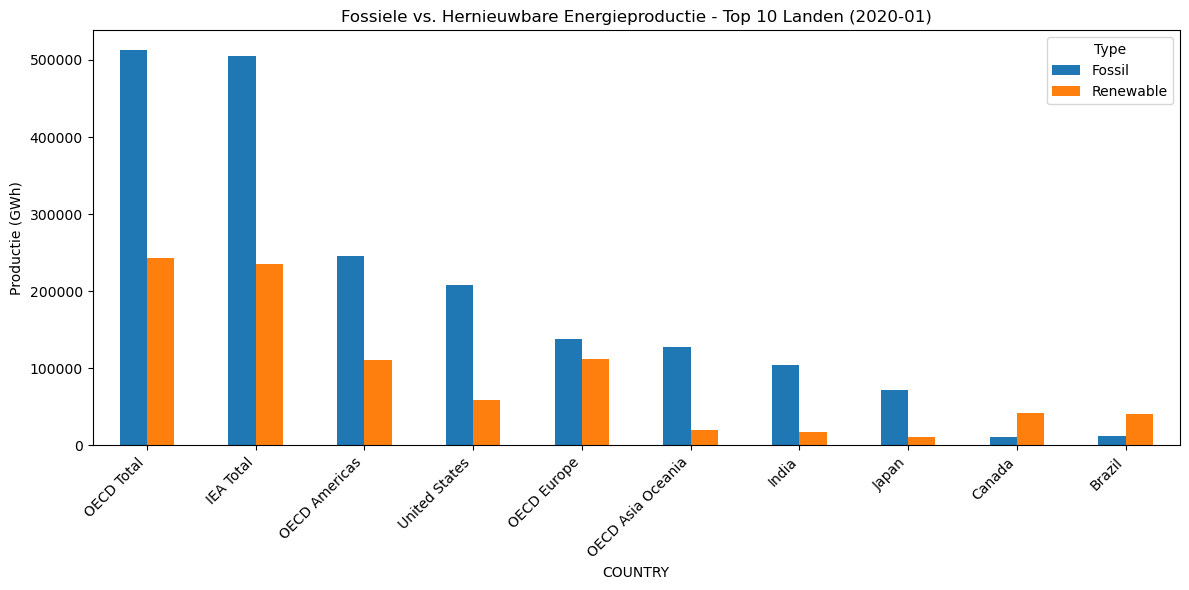

In [10]:
# Kies één maand/jaar
year = 2020
month = 1

df = monthly_df[(monthly_df['YEAR'] == year) & (monthly_df['MONTH'] == month)].copy()

# Alleen relevante bronnen
df = df[df['PRODUCT'].isin(['Total combustible fuels', 'Solar', 'Wind', 'Hydro'])]

# Categoriseer als 'Fossil' of 'Renewable'
def label_type(product):
    return 'Fossil' if product == 'Total combustible fuels' else 'Renewable'

df['Type'] = df['PRODUCT'].apply(label_type)

# Groepeer productie per land per type
agg = df.groupby(['COUNTRY', 'Type'])['VALUE'].sum().unstack().fillna(0)

# Top 10 landen met hoogste totale productie
top_countries = agg.sum(axis=1).sort_values(ascending=False).head(10)
top_agg = agg.loc[top_countries.index]

# Plot
top_agg.plot(kind='bar', figsize=(12, 6), stacked=False)
plt.title(f"Fossiele vs. Hernieuwbare Energieproductie - Top 10 Landen ({year}-{month:02})")
plt.ylabel("Productie (GWh)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


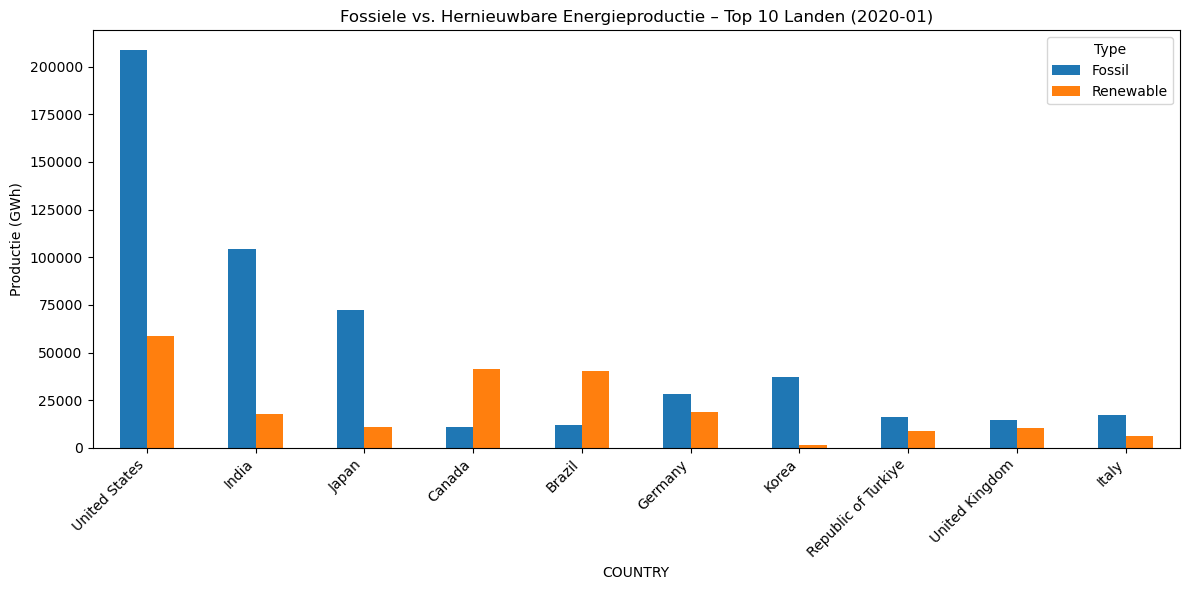

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset inladen
monthly_df = pd.read_csv("data.csv")

# ❌ Lijst met niet-landen uitsluiten
exclude_entities = [
    'World', 'Africa', 'Asia', 'Europe', 'North America', 'South America',
    'European Union (27)', 'European Union (28)', 'OECD', 'Non-OECD',
    'Non-OECD Asia', 'Non-OECD Europe and Eurasia', 'Middle East', 'Eurasia',
    'Other Asia Pacific', 'Central & South America', 'IEA Net Zero by 2050 scenario',
    'IEA Total', 'IEA Europe', 'IEA Americas', 'IEA Asia Oceania',
    'OECD Total', 'OECD Americas', 'OECD Europe', 'OECD Asia Oceania'
]

# 📅 Filter op jaar + maand
year = 2020
month = 1
df = monthly_df[(monthly_df['YEAR'] == year) & (monthly_df['MONTH'] == month)].copy()

# 🔌 Alleen gewenste producten
df = df[df['PRODUCT'].isin(['Total combustible fuels', 'Solar', 'Wind', 'Hydro'])]

# 🧹 Verwijder niet-landen
df = df[~df['COUNTRY'].isin(exclude_entities)]

# 🌱 Label 'Fossil' of 'Renewable'
df['Type'] = df['PRODUCT'].apply(lambda x: 'Fossil' if x == 'Total combustible fuels' else 'Renewable')

# 📊 Groepeer per land/type
agg = df.groupby(['COUNTRY', 'Type'])['VALUE'].sum().unstack().fillna(0)

# 🔝 Top 10 landen met hoogste totale productie
top_countries = agg.sum(axis=1).sort_values(ascending=False).head(10)
top_agg = agg.loc[top_countries.index]

# 📈 Plot de bar chart
top_agg.plot(kind='bar', figsize=(12, 6), stacked=False)
plt.title(f"Fossiele vs. Hernieuwbare Energieproductie – Top 10 Landen ({year}-{month:02})")
plt.ylabel("Productie (GWh)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()







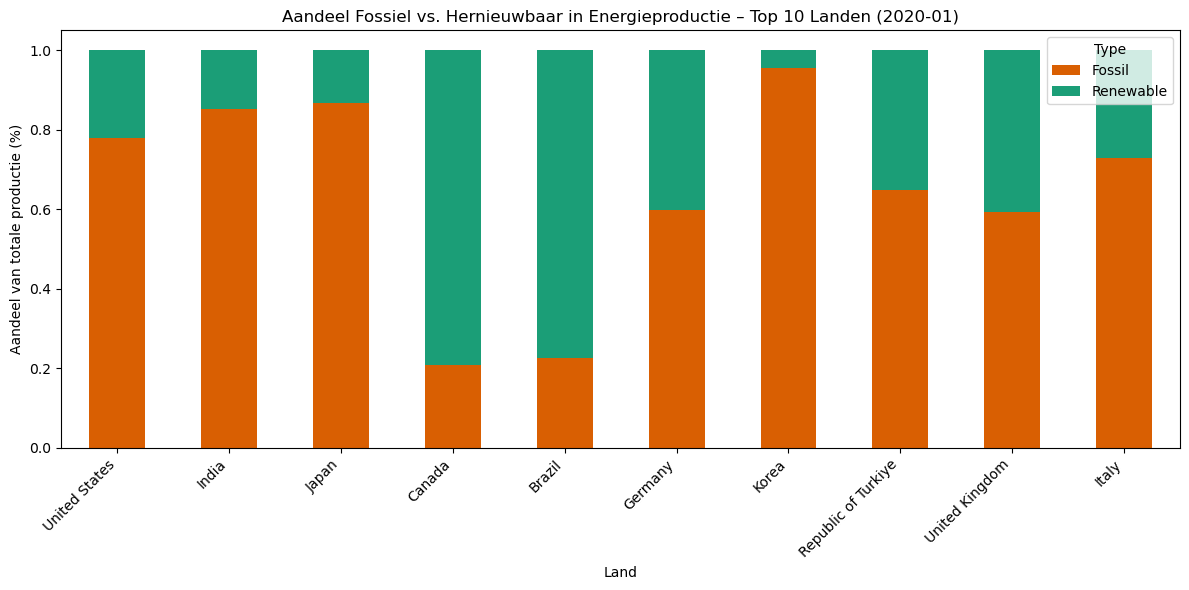

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset laden
monthly_df = pd.read_csv("data.csv")

# Aggregaten uitsluiten
exclude_entities = [
    'World', 'Africa', 'Asia', 'Europe', 'North America', 'South America',
    'European Union (27)', 'European Union (28)', 'OECD', 'Non-OECD',
    'Non-OECD Asia', 'Non-OECD Europe and Eurasia', 'Middle East', 'Eurasia',
    'Other Asia Pacific', 'Central & South America', 'IEA Net Zero by 2050 scenario',
    'IEA Total', 'IEA Europe', 'IEA Americas', 'IEA Asia Oceania',
    'OECD Total', 'OECD Americas', 'OECD Europe', 'OECD Asia Oceania'
]

# Filter op maand en jaar
year = 2020
month = 1
df = monthly_df[(monthly_df['YEAR'] == year) & (monthly_df['MONTH'] == month)].copy()

# Alleen gewenste energiebronnen
df = df[df['PRODUCT'].isin(['Total combustible fuels', 'Solar', 'Wind', 'Hydro'])]

# Alleen echte landen
df = df[~df['COUNTRY'].isin(exclude_entities)]

# Label 'Fossil' of 'Renewable'
df['Type'] = df['PRODUCT'].apply(lambda x: 'Fossil' if x == 'Total combustible fuels' else 'Renewable')

# Groepeer per land en type
agg = df.groupby(['COUNTRY', 'Type'])['VALUE'].sum().unstack().fillna(0)

# Kies top 10 landen met hoogste totale productie
top_countries = agg.sum(axis=1).sort_values(ascending=False).head(10)
top_agg = agg.loc[top_countries.index]

# Omzetten naar percentage
top_agg_percent = top_agg.div(top_agg.sum(axis=1), axis=0)

# Plot
top_agg_percent.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#d95f02', '#1b9e77'])
plt.title(f"Aandeel Fossiel vs. Hernieuwbaar in Energieproductie – Top 10 Landen ({year}-{month:02})")
plt.ylabel("Aandeel van totale productie (%)")
plt.xlabel("Land")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Type")
plt.tight_layout()
plt.show()


In [42]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
import numpy as np

# === 1. Data inladen
df = pd.read_csv("global-data-on-sustainable-energy (1).csv")  # pas naam aan indien nodig

# === 2. Aggregaten verwijderen
exclude_entities = [
    'World', 'Africa', 'Asia', 'Europe', 'North America', 'South America',
    'European Union (27)', 'European Union (28)', 'OECD', 'Non-OECD',
    'Non-OECD Asia', 'Non-OECD Europe and Eurasia', 'Middle East', 'Eurasia',
    'Other Asia Pacific', 'Central & South America', 'IEA Net Zero by 2050 scenario',
    'IEA Total', 'IEA Europe', 'IEA Americas', 'IEA Asia Oceania',
    'OECD Total', 'OECD Americas', 'OECD Europe', 'OECD Asia Oceania'
]
df = df[~df['Entity'].isin(exclude_entities)]

# === 3. Relevante kolommen
x_col = 'gdp_per_capita'
y_col = 'Renewable energy share in the total final energy consumption (%)'
size_col = 'Access to electricity (% of population)'

# Alleen landen met complete gegevens
df = df[['Entity', 'Year', x_col, y_col, size_col]].dropna()

# === 4. Laatste beschikbare jaar per land
latest_df = df.loc[df.groupby('Entity')['Year'].idxmax()].copy()

# === 5. Selecteer top 10 & bottom 10 op renewable share
sorted_df = latest_df.sort_values(by=y_col)
subset_df = pd.concat([sorted_df.head(10), sorted_df.tail(10)])

# === 6. Medianen berekenen
x_median = latest_df[x_col].median()
y_median = latest_df[y_col].median()

# === 7. Trendlijn
X = subset_df[[x_col]].values
Y = subset_df[[y_col]].values
model = LinearRegression()
model.fit(X, Y)
trend_x = np.linspace(X.min(), X.max(), 100)
trend_y = model.predict(trend_x.reshape(-1, 1))

# === 8. Bubble scatterplot
fig = px.scatter(
    subset_df,
    x=x_col,
    y=y_col,
    size=size_col,
    hover_name="Entity",
    size_max=40,
    opacity=0.8,
    height=600,
    width=1400,
    color=y_col,
    color_continuous_scale="Viridis",
    labels={
        x_col: "GDP per Capita",
        y_col: "Renewable Energy Share (%)",
        size_col: "Electricity Access (%)"
    },
    title="Top & Bottom 10: Sustainability vs GDP per Capita – Kwadrantanalyse"
)

# === 9. Trendlijn toevoegen
fig.add_trace(go.Scatter(
    x=trend_x.flatten(),
    y=trend_y.flatten(),
    mode='lines',
    name='Trendline',
    line=dict(color='white', dash='dash')
))

# === 10. Kwadrantlijnen
fig.add_shape(type="line",
    x0=x_median, y0=subset_df[y_col].min(),
    x1=x_median, y1=subset_df[y_col].max(),
    line=dict(color="lightgray", width=1, dash="dot")
)
fig.add_shape(type="line",
    x0=subset_df[x_col].min(), y0=y_median,
    x1=subset_df[x_col].max(), y1=y_median,
    line=dict(color="lightgray", width=1, dash="dot")
)

# === 11. Symmetrische assen
x_range = max(x_median - subset_df[x_col].min(), subset_df[x_col].max() - x_median)
y_range = max(y_median - subset_df[y_col].min(), subset_df[y_col].max() - y_median)
fig.update_layout(
    xaxis=dict(range=[x_median - x_range, x_median + x_range]),
    yaxis=dict(range=[y_median - y_range, y_median + y_range])
)

# === 12. Kwadrantlabels
quadrant_labels = [
    ("💰🌪 High GDP, Low Renewable", x_median + x_range * 0.6, y_median - y_range * 0.6),
    ("🌱💰 High GDP, High Renewable", x_median + x_range * 0.6, y_median + y_range * 0.6),
    ("⚠️ Low GDP, Low Renewable", x_median - x_range * 0.6, y_median - y_range * 0.6),
    ("🌍💡 Low GDP, High Renewable", x_median - x_range * 0.6, y_median + y_range * 0.6)
]

for text, x, y in quadrant_labels:
    fig.add_annotation(
        text=text,
        x=x,
        y=y,
        showarrow=False,
        font=dict(size=12),
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="gray",
        borderwidth=1
    )

# === 13. Toelichting onderaan (zoals voorbeeld)
fig.add_annotation(
    text="Deze grafiek toont het contrast tussen de 10 landen met de hoogste en laagste hernieuwbare energiedeling.<br>"
         "De lijnen markeren het mediane GDP per capita en het mediane aandeel hernieuwbare energie.<br>"
         "De trendlijn toont dat hogere GDP niet automatisch leidt tot meer duurzaamheid.",
    align='left',
    showarrow=False,
    xref='paper', yref='paper',
    x=0, y=-0.35,
    bordercolor="lightgray",
    borderwidth=1,
    bgcolor="rgba(255,255,255,0.9)",
    font=dict(size=12),
)

# === 14. Layout afronden
fig.update_layout(template='simple_white', margin=dict(l=50, r=50, t=80, b=120))

# === 15. Tonen
fig.show()


